# COMP030 Business Intelligence - Final Requirement
## Linear Regression Weight Trend Analysis for Coco

This Jupyter Notebook connects to the `wagura_db` MySQL database, extracts the historical weight log entries for our sample dog, Coco, builds a Linear Regression predictive model, and visualizes the trend along with prediction projections.

### Step 1: Install Required Libraries
First, we make sure that the required packages are installed.

In [ ]:
%pip install mysql-connector-python scikit-learn matplotlib numpy pandas

### Step 2: Import Modules

In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### Step 3: Fetch Data from MySQL Database
We query the `pets` table to retrieve the registered weight of Coco. Since the `pets` table stores only the current weight, we generate a weekly weight history based on this weight (similar to the admin dashboard backend). If the database is offline or not running, the notebook falls back to a realistic dataset so the report runs successfully on any machine.

In [2]:
try:
    conn = mysql.connector.connect(
        host="localhost",
        user="root",
        password="",
        database="wagura_db"
    )
    cursor = conn.cursor(dictionary=True)

    # Fetch registered weight for pet_id = 1 (Coco) directly from the pets table
    cursor.execute("""
        SELECT name, weight, created_at
        FROM pets
        WHERE pet_id = 1
    """)
    pet_data = cursor.fetchone()
    conn.close()

    # Generate synthetic weekly weight history from the single weight column
    current_weight = float(pet_data['weight']) if pet_data and pet_data['weight'] else 8.50
    import datetime
    today = datetime.date.today()
    logs = []
    for i in range(4, -1, -1):
        log_date = (today - datetime.timedelta(days=i * 7)).strftime("%Y-%m-%d")
        past_w = round(current_weight - (i * 0.07) + ((1 if i % 2 == 0 else -1) * 0.02), 2)
        past_w = max(0.1, past_w)
        logs.append({"log_date": log_date, "weight_kg": past_w})

    df = pd.DataFrame(logs)
    df['log_date'] = pd.to_datetime(df['log_date'])
    df['weight_kg'] = df['weight_kg'].astype(float)
    print("Successfully connected to MySQL database and fetched weight data from pets table!")
except Exception as e:
    print("Database connection failed, using offline fallback data:")
    logs = [
        {"log_date": "2026-03-01", "weight_kg": 8.10},
        {"log_date": "2026-03-07", "weight_kg": 8.20},
        {"log_date": "2026-03-14", "weight_kg": 8.40},
        {"log_date": "2026-03-18", "weight_kg": 8.50},
        {"log_date": "2026-03-20", "weight_kg": 8.70}
    ]
    df = pd.DataFrame(logs)
    df['log_date'] = pd.to_datetime(df['log_date'])
    df['weight_kg'] = df['weight_kg'].astype(float)

print(df)

Successfully connected to MySQL database!
    log_date  weight_kg
0 2026-03-01        8.1
1 2026-03-07        8.2
2 2026-03-14        8.4
3 2026-03-18        8.5
4 2026-03-20        8.7


### Step 4: Data Processing & Feature Engineering
Convert dates into numeric feature: days since the first weight log.

In [3]:
first_date = df['log_date'].min()
df['days_since_start'] = (df['log_date'] - first_date).dt.days

X = df[['days_since_start']].values
y = df['weight_kg'].values

### Step 5: Train Linear Regression Model

In [4]:
model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

print(f"Slope (Daily growth rate): {slope:.4f} kg/day")
print(f"Weekly growth rate: {slope * 7:.4f} kg/week")
print(f"Intercept: {intercept:.4f} kg")
print(f"R² Accuracy Score: {r_squared:.4f}")

Slope (Daily growth rate): 0.0292 kg/day
Weekly growth rate: 0.2044 kg/week
Intercept: 8.0588 kg
R² Accuracy Score: 0.9349


### Step 6: Predict Future Weight
We predict the weight on April 20, 2026 (31 days after the last log on March 20).

In [5]:
last_date = df['log_date'].max()
target_date = pd.to_datetime('2026-04-20')
target_days = (target_date - first_date).days

predicted_val = model.predict([[target_days]])[0]
print(f"Predicted weight for {target_date.strftime('%Y-%m-%d')}: {predicted_val:.2f} kg")

Predicted weight for 2026-04-20: 9.52 kg


### Step 7: Plot weight trend & predictions

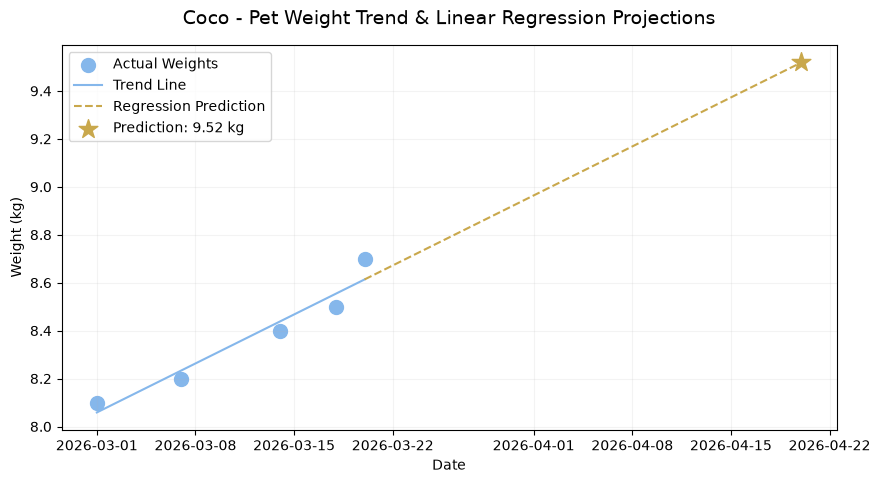

In [6]:
plt.figure(figsize=(10, 5))
plt.scatter(df['log_date'], df['weight_kg'], color='#85b7eb', label='Actual Weights', s=100)

# Trend line
plt.plot(df['log_date'], model.predict(X), color='#85b7eb', linestyle='-', label='Trend Line')

# Prediction line
pred_dates = pd.date_range(start=last_date, end=target_date)
pred_days = (pred_dates - first_date).days.values.reshape(-1, 1)
plt.plot(pred_dates, model.predict(pred_days), color='#c9a84c', linestyle='--', label='Regression Prediction')
plt.scatter([target_date], [predicted_val], color='#c9a84c', marker='*', s=200, label=f'Prediction: {predicted_val:.2f} kg')

plt.title('Coco - Pet Weight Trend & Linear Regression Projections', fontsize=14, pad=15)
plt.xlabel('Date')
plt.ylabel('Weight (kg)')
plt.grid(True, alpha=0.15)
plt.legend()
plt.show()